# Task 2 — Step 1: Source-Only ERM Baseline & the Unadapted Domain Gap

**Setting.** Unsupervised domain adaptation on PACS: labeled sources `photo`, `art_painting`, `cartoon`; unlabeled target `sketch`. Same 7 classes everywhere.

**Objective (ERM on domain-balanced batches).**
$$\mathcal{L}_{\text{ERM}}(\theta)=\frac{1}{3}\sum_{e\in\{P,A,C\}}\mathbb{E}_{(x,y)\sim\mathcal{D}_e}\,\ell_{\text{CE}}\big(C(F(x)),y\big)$$
Each update draws 8 images from each source domain (24 total), so every source domain has equal influence.

**Protocol (manual, shared by every Task 2/3 method).**
| Item | Setting |
|---|---|
| Backbone | torchvision ResNet-18, `IMAGENET1K_V1`, new 7-way linear head, full fine-tuning |
| Pre-processing | Resize 256×256 → **RandomCrop 224** + horizontal flip (train); CenterCrop 224 (eval); ImageNet normalisation |
| BatchNorm | running mean/var **frozen** at ImageNet values (BN modules in eval mode after `model.train()`); γ, β trainable |
| Optimiser | AdamW, lr 1e-4, wd 1e-4 |
| Budget / selection | ≤ 30 epochs; early stop after 5 epochs without improvement in **mean source-validation macro-F1** (budget: `MAX_EPOCHS` / `PATIENCE` in `shared/src/pacs_protocol.py` = 30 / 5, as the manual specifies) |
| Splits | stratified 80/20 per source domain, seed 6304 (`shared/splits/pacs_sketch_seed6304.json`) |

This checkpoint is reused **unchanged** as the Task 3 ERM baseline. Sketch labels are read only in Section 7, after the checkpoint is locked.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, torch.nn as nn
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import PACSDataset, get_pacs_dataloaders, PACS_DOMAINS, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.pacs_protocol import TRAIN_TRANSFORM, freeze_bn_stats, MAX_EPOCHS, PATIENCE
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, bar_labels, save_show
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.train import train_source_only
from task2_domain_adaptation.src.evaluate import evaluate_source_validation, evaluate_target

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
RES = os.path.join(ROOT, 'task2_domain_adaptation', 'results')
os.makedirs(CKPT, exist_ok=True); os.makedirs(RES, exist_ok=True)
print(f"device={device} | seed={SEED} | train transform: {TRAIN_TRANSFORM.transforms[1]}")

device=cuda | seed=6304 | train transform: RandomCrop(size=(224, 224), padding=None)


## 1. Data and shared splits

In [2]:
src_train, src_val, tgt_train, tgt_eval = get_pacs_dataloaders(DATA, SPLIT, source_batch_size=8, target_batch_size=24, eval_batch_size=64)
rows = []
for d in PACS_SOURCE_DOMAINS:
    rows.append({'domain': d, 'role': 'source', 'train': len(src_train[d].dataset), 'val': len(src_val[d].dataset)})
rows.append({'domain': 'sketch', 'role': 'target (unlabeled during training)', 'train': len(tgt_eval.dataset), 'val': 0})
pd.DataFrame(rows).set_index('domain')

,role,train,val
domain,,,
photo,source,1336,334
art_painting,source,1638,410
cartoon,source,1875,469
sketch,target (unlabeled during training),3929,0


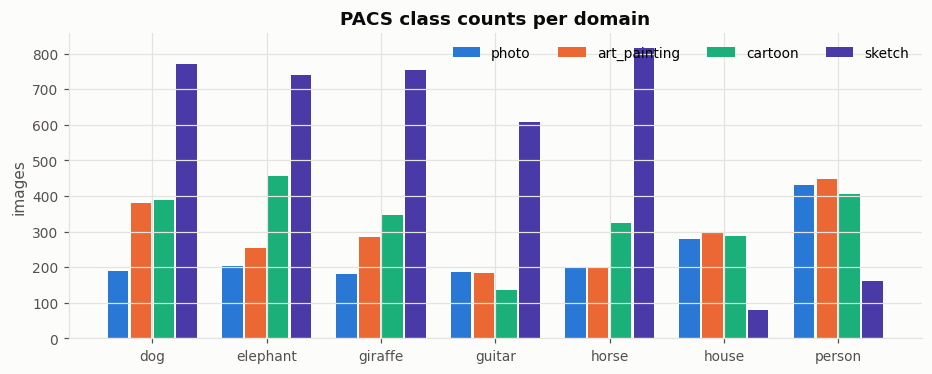

In [3]:
# Class balance per domain (source labels only for the sources; sketch label counts are
# dataset metadata shown for completeness and are not used by any training decision).
counts = {}
for d in PACS_DOMAINS:
    labels = [l for _, l in PACSDataset(DATA, d).samples]
    counts[d] = np.bincount(labels, minlength=7)
df_counts = pd.DataFrame(counts, index=PACS_CLASSES)
fig, ax = plt.subplots(figsize=(10, 3.6))
w = 0.2
for i, d in enumerate(PACS_DOMAINS):
    ax.bar(np.arange(7) + (i - 1.5) * w, df_counts[d], w * 0.9, color=DOMAIN_COLORS[d], label=d)
ax.set_xticks(range(7)); ax.set_xticklabels(PACS_CLASSES)
ax.set_ylabel('images'); ax.set_title('PACS class counts per domain'); ax.legend(ncol=4)
save_show(fig, os.path.join(RES, 'pacs_class_counts.png'))

## 2. Domain gallery
The Sketch domain removes colour, texture and shading and keeps only contours — a severe covariate shift for a network fine-tuned on photos, paintings and cartoons.

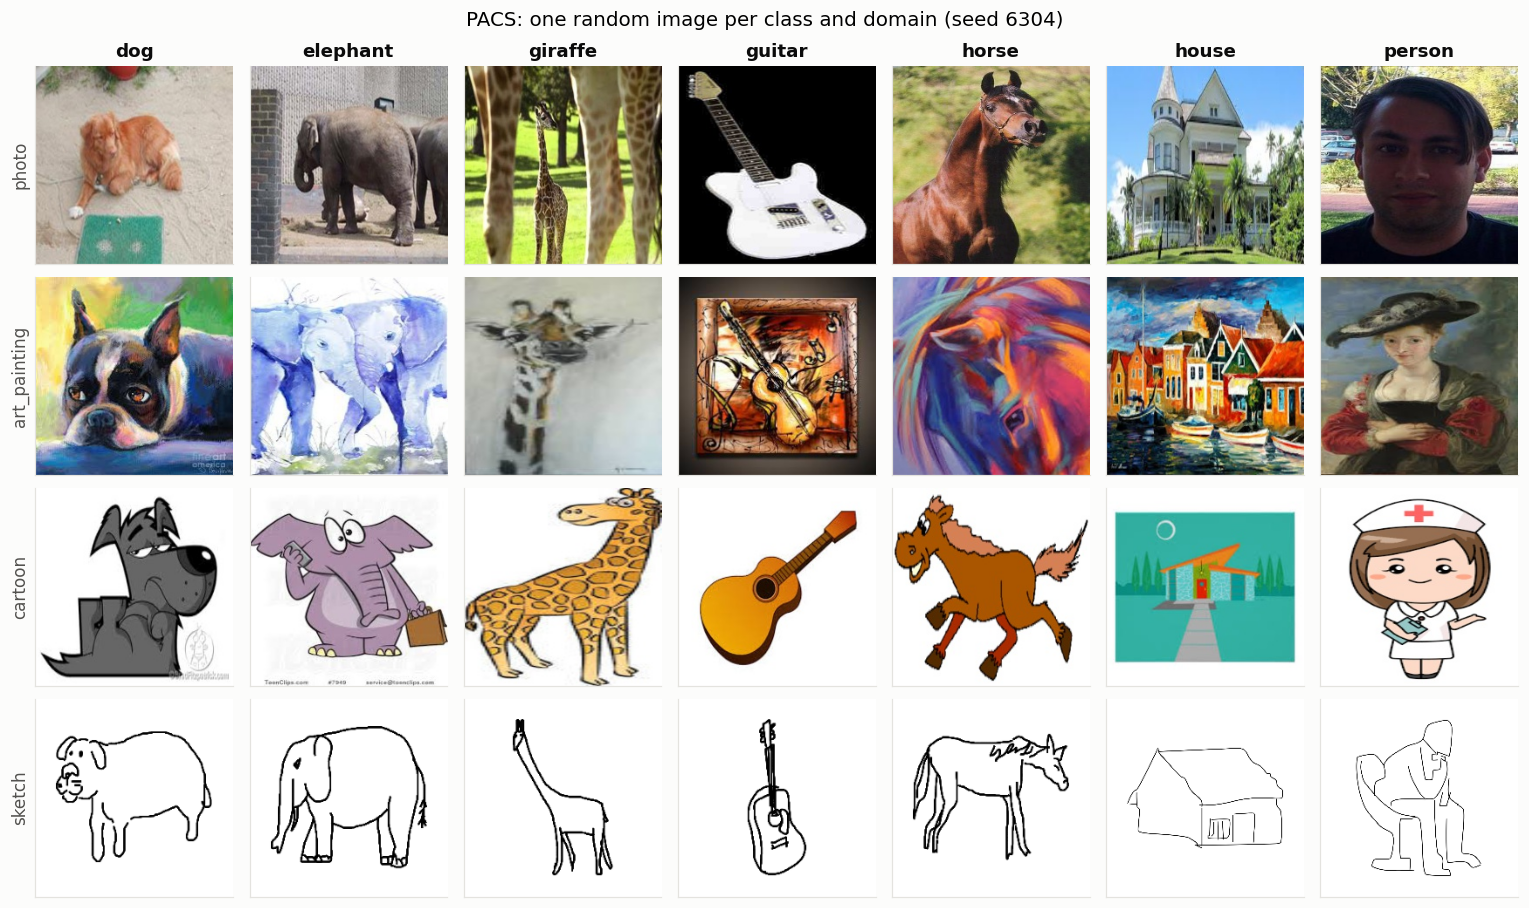

In [4]:
rng = np.random.RandomState(SEED)
fig, axes = plt.subplots(4, 7, figsize=(14, 8.4))
for r, d in enumerate(PACS_DOMAINS):
    ds = PACSDataset(DATA, d)
    by_cls = {}
    for i, (_, l) in enumerate(ds.samples):
        by_cls.setdefault(l, []).append(i)
    for c in range(7):
        img, _ = ds[int(rng.choice(by_cls[c]))]
        ax = axes[r, c]; ax.imshow(img); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r == 0: ax.set_title(PACS_CLASSES[c])
        if c == 0: ax.set_ylabel(d, fontsize=11)
fig.suptitle('PACS: one random image per class and domain (seed 6304)', fontsize=13)
fig.tight_layout()
save_show(fig, os.path.join(RES, 'pacs_domain_gallery.png'))

## 3. Model and BatchNorm policy check

In [5]:
model = ResNet18Backbone(num_classes=7).to(device)
model.train(); freeze_bn_stats(model)
bn = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]
assert all(not m.training for m in bn) and all(m.weight.requires_grad and m.bias.requires_grad for m in bn)
ref_mean = bn[0].running_mean.clone()
with torch.no_grad():
    model(torch.randn(8, 3, 224, 224, device=device))
assert torch.equal(ref_mean, bn[0].running_mean), 'BN running stats changed in train mode!'
print(f"{len(bn)} BatchNorm layers: running stats frozen (verified unchanged after a forward pass), gamma/beta trainable")
print(f"trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

20 BatchNorm layers: running stats frozen (verified unchanged after a forward pass), gamma/beta trainable
trainable parameters: 11,180,103


## 4. Train Source-only ERM
Set `FORCE_TRAIN = False` to reload the saved checkpoint and history instead of retraining.

In [6]:
FORCE_TRAIN = True
ckpt_path = os.path.join(CKPT, 'source_only.pth')
hist_path = os.path.join(CKPT, 'source_only_history.json')
CONFIG = dict(method='source_only', lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_per_source_domain=8,
              train_transform='Resize(256,256)+RandomCrop(224)+HFlip', seed=SEED)

if FORCE_TRAIN or not os.path.exists(ckpt_path):
    set_seed(SEED)
    model = ResNet18Backbone(num_classes=7)
    out = train_source_only(model, src_train, src_val, device, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=1e-4, wd=1e-4, save_path=ckpt_path)
    history, best_epoch, best_f1 = out['history'], out['best_epoch'], out['best_f1']
    json.dump({'config': CONFIG, 'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1}, open(hist_path, 'w'), indent=1)
else:
    meta = json.load(open(hist_path)); history, best_epoch, best_f1 = meta['history'], meta['best_epoch'], meta['best_f1']
model = ResNet18Backbone(num_classes=7).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
print(f"selected epoch {best_epoch} | mean source-val macro-F1 {best_f1:.4f}")

[source_only] ep  1 | cls 0.485 | val F1 0.8834 *
[source_only] ep  2 | cls 0.197 | val F1 0.8983 *
[source_only] ep  3 | cls 0.137 | val F1 0.9325 *
[source_only] ep  4 | cls 0.124 | val F1 0.9224
[source_only] ep  5 | cls 0.100 | val F1 0.8763
[source_only] ep  6 | cls 0.096 | val F1 0.9135
[source_only] ep  7 | cls 0.070 | val F1 0.9290
[source_only] ep  8 | cls 0.048 | val F1 0.9376 *
[source_only] ep  9 | cls 0.055 | val F1 0.8341
[source_only] ep 10 | cls 0.061 | val F1 0.9194
[source_only] ep 11 | cls 0.060 | val F1 0.9121
[source_only] ep 12 | cls 0.055 | val F1 0.9329
[source_only] ep 13 | cls 0.027 | val F1 0.9262
Early stopping at epoch 13; best epoch 8 (val F1 0.9376)
selected epoch 8 | mean source-val macro-F1 0.9376


## 5. Training curves

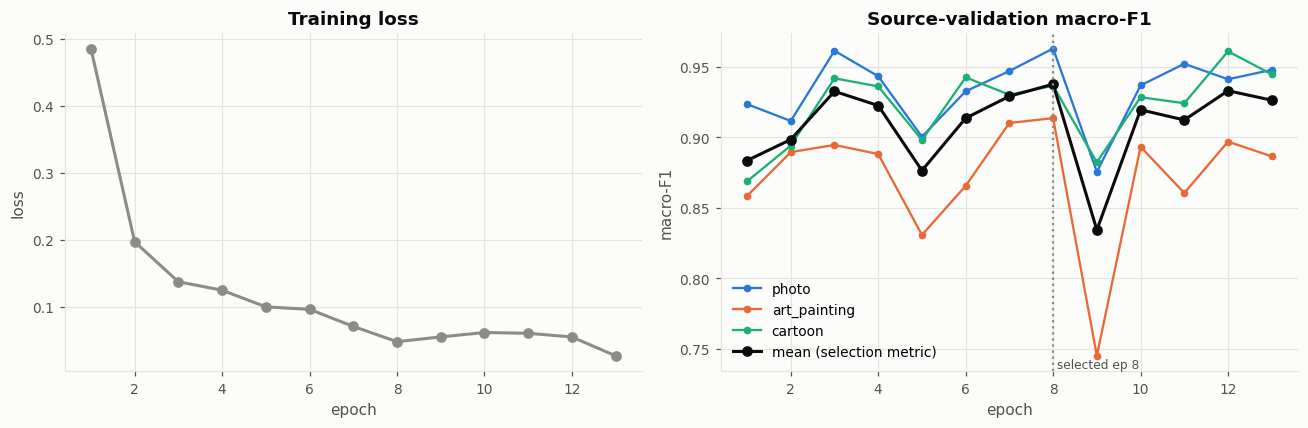

In [7]:
ep = np.arange(1, len(history['train_loss']) + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(ep, history['cls_loss'], 'o-', color=NEUTRAL, label='source CE')
a1.set_xlabel('epoch'); a1.set_ylabel('loss'); a1.set_title('Training loss')
for d in PACS_SOURCE_DOMAINS:
    a2.plot(ep, history['val_per_domain'][d]['f1'], 'o-', ms=4, lw=1.5, color=DOMAIN_COLORS[d], label=d)
a2.plot(ep, history['val_mean_f1'], 'o-', color='#0b0b0b', label='mean (selection metric)')
a2.axvline(best_epoch, color=NEUTRAL, ls=':', lw=1.5); a2.text(best_epoch, a2.get_ylim()[0], f' selected ep {best_epoch}', color='#52514e', fontsize=8, va='bottom')
a2.set_xlabel('epoch'); a2.set_ylabel('macro-F1'); a2.set_title('Source-validation macro-F1'); a2.legend()
fig.tight_layout()
save_show(fig, os.path.join(RES, 'source_only_training_curves.png'))

## 6. Source-validation results (locked checkpoint)

In [8]:
src_metrics = evaluate_source_validation(model, src_val, device)
tab = pd.DataFrame({d: {'acc (%)': 100 * src_metrics[d]['acc'], 'macro-F1 (%)': 100 * src_metrics[d]['f1']} for d in PACS_SOURCE_DOMAINS}).T
tab.loc['mean'] = [100 * src_metrics['mean_acc'], 100 * src_metrics['mean_f1']]
tab.loc['worst'] = tab.loc[PACS_SOURCE_DOMAINS].min()
tab.round(2)

,acc (%),macro-F1 (%)
photo,96.71,96.28
art_painting,91.46,91.35
cartoon,93.18,93.64
mean,93.78,93.76
worst,91.46,91.35


## 7. Target (Sketch) evaluation — the unadapted domain gap
The checkpoint is fixed at this point; Sketch labels are used only to measure it.

In [9]:
tgt = evaluate_target(model, tgt_eval, device)
gap = 100 * (src_metrics['mean_acc'] - tgt['acc'])
print(f"mean source-val acc {100*src_metrics['mean_acc']:.2f}% | Sketch acc {100*tgt['acc']:.2f}% | Sketch macro-F1 {100*tgt['f1']:.2f}%")
print(f"domain gap (mean source-val acc - Sketch acc): {gap:.2f} percentage points")
summary = pd.DataFrame([{
    'Photo Val Acc': src_metrics['photo']['acc'], 'Art Val Acc': src_metrics['art_painting']['acc'], 'Cartoon Val Acc': src_metrics['cartoon']['acc'],
    'Photo Val F1': src_metrics['photo']['f1'], 'Art Val F1': src_metrics['art_painting']['f1'], 'Cartoon Val F1': src_metrics['cartoon']['f1'],
    'Mean Source Val Acc': src_metrics['mean_acc'], 'Mean Source Val F1': src_metrics['mean_f1'],
    'Target (Sketch) Acc': tgt['acc'], 'Target (Sketch) F1': tgt['f1'], 'Domain Gap': gap / 100}], index=['Source-Only ERM'])
summary.to_csv(os.path.join(RES, 'source_only_summary.csv'))
summary.T.round(4)

mean source-val acc 93.78% | Sketch acc 59.23% | Sketch macro-F1 66.06%
domain gap (mean source-val acc - Sketch acc): 34.56 percentage points


,Source-Only ERM
Photo Val Acc,0.9671
Art Val Acc,0.9146
Cartoon Val Acc,0.9318
Photo Val F1,0.9628
Art Val F1,0.9135
Cartoon Val F1,0.9364
Mean Source Val Acc,0.9378
Mean Source Val F1,0.9376
Target (Sketch) Acc,0.5923
Target (Sketch) F1,0.6606


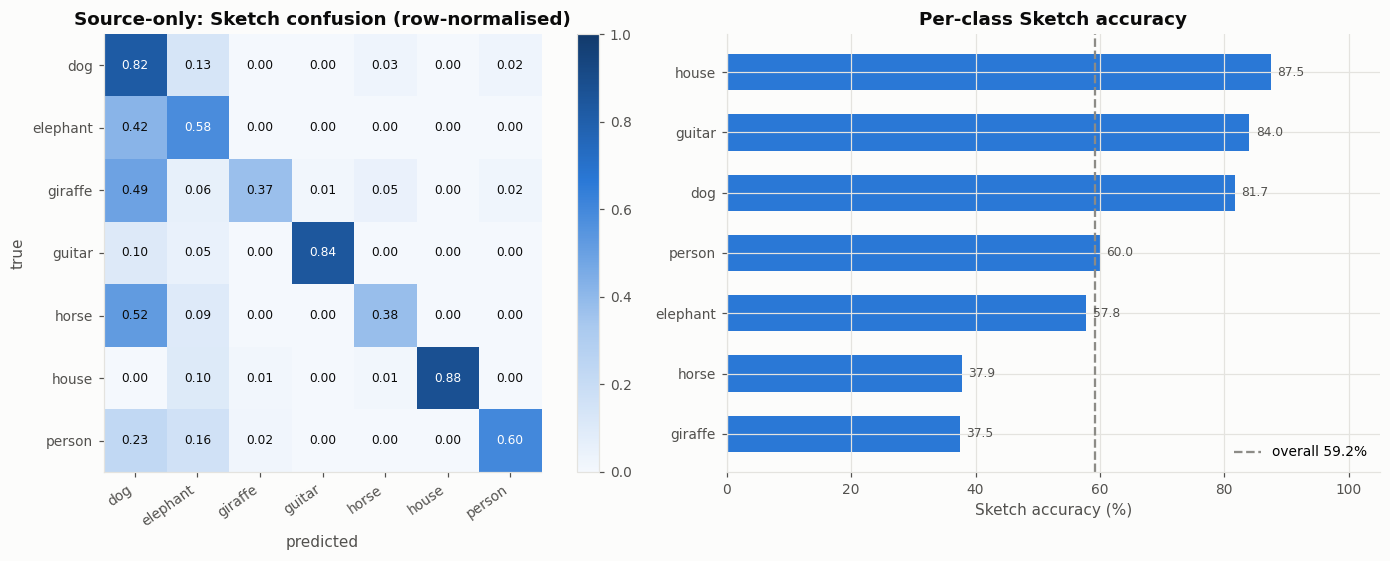

In [10]:
cm = tgt['confusion_matrix']; cm_n = cm / cm.sum(1, keepdims=True)
pc = np.array(tgt['per_class_acc']) * 100
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1.1, 1]})
im = a1.imshow(cm_n, cmap=SEQ_CMAP, vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        a1.text(j, i, f"{cm_n[i, j]:.2f}", ha='center', va='center', fontsize=8, color='white' if cm_n[i, j] > 0.55 else '#0b0b0b')
a1.set_xticks(range(7)); a1.set_xticklabels(PACS_CLASSES, rotation=35, ha='right'); a1.set_yticks(range(7)); a1.set_yticklabels(PACS_CLASSES)
a1.set_xlabel('predicted'); a1.set_ylabel('true'); a1.set_title('Source-only: Sketch confusion (row-normalised)'); a1.grid(False)
fig.colorbar(im, ax=a1, fraction=0.046)
order = np.argsort(pc)
bars = a2.barh(np.array(PACS_CLASSES)[order], pc[order], color=PALETTE[0], height=0.6)
a2.axvline(100 * tgt['acc'], color=NEUTRAL, ls='--', lw=1.5, label=f"overall {100*tgt['acc']:.1f}%")
for b in bars:
    a2.text(b.get_width() + 1, b.get_y() + b.get_height() / 2, f"{b.get_width():.1f}", va='center', fontsize=8, color='#52514e')
a2.set_xlim(0, 105); a2.set_xlabel('Sketch accuracy (%)'); a2.set_title('Per-class Sketch accuracy'); a2.legend(loc='lower right')
fig.tight_layout()
save_show(fig, os.path.join(RES, 'source_only_target_analysis.png'))

In [11]:
# Dominant confusions (largest off-diagonal row-normalised entries)
off = [(PACS_CLASSES[i], PACS_CLASSES[j], cm_n[i, j], cm[i, j]) for i in range(7) for j in range(7) if i != j]
pd.DataFrame(sorted(off, key=lambda t: -t[2])[:6], columns=['true', 'predicted', 'rate', 'count']).round(3)

,true,predicted,rate,count
0,horse,dog,0.522,426
1,giraffe,dog,0.491,370
2,elephant,dog,0.418,309
3,person,dog,0.225,36
4,person,elephant,0.156,25
5,dog,elephant,0.130,100


## 8. Failure gallery
Random misclassified sketches (seed 6304) with the source-only prediction and its confidence.

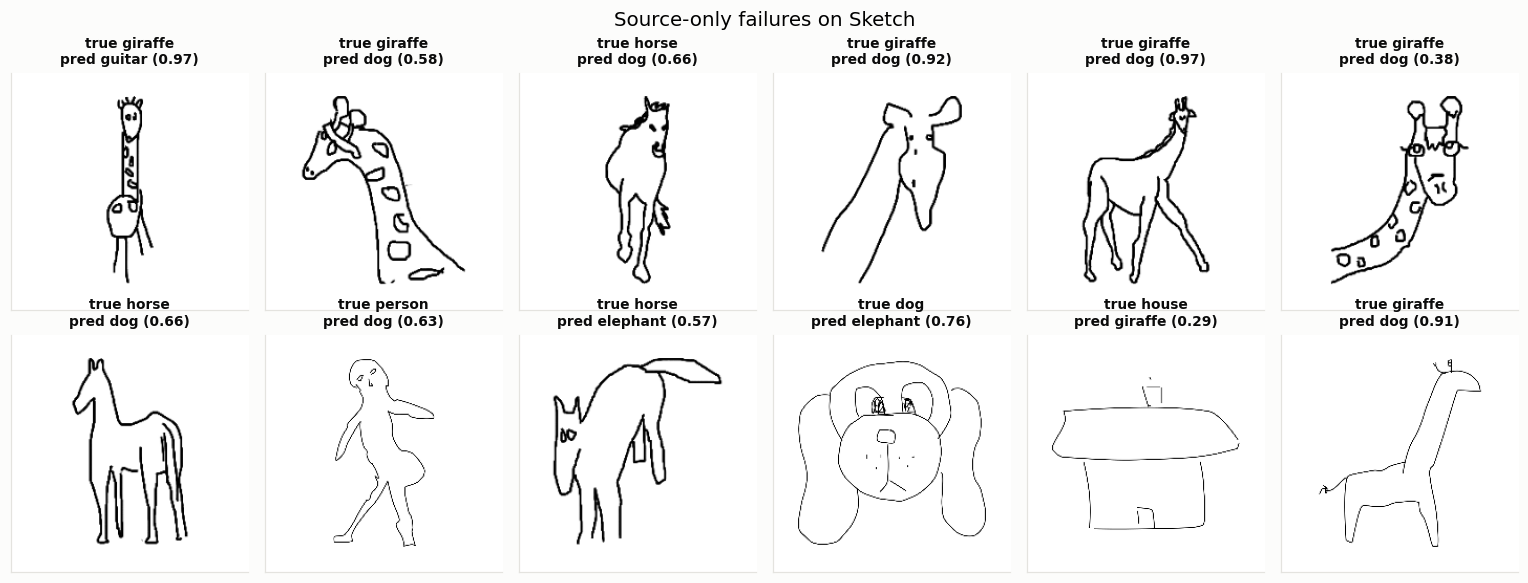

In [12]:
ds_raw = PACSDataset(DATA, 'sketch')
with torch.no_grad():
    model.eval()
    probs = torch.cat([torch.softmax(model(x.to(device))[0], 1).cpu() for x, _ in tgt_eval]).numpy()
wrong = np.where(tgt['preds'] != tgt['targets'])[0]
pick = np.random.RandomState(SEED).choice(wrong, 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(14, 5.4))
for ax, i in zip(axes.ravel(), pick):
    ax.imshow(ds_raw[int(i)][0]); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"true {PACS_CLASSES[tgt['targets'][i]]}\npred {PACS_CLASSES[tgt['preds'][i]]} ({probs[i].max():.2f})", fontsize=9)
fig.suptitle('Source-only failures on Sketch', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'source_only_failures.png'))

## 9. Evidence for Research Question 1
*How large is the source-to-target domain gap for Source-only ERM, and which classes account for the most important failures?*

The cell below prints the facts the report needs (gap, weakest classes, dominant confusions). Interpretation is left to the report.

In [13]:
worst = np.argsort(pc)[:3]
print(f"Domain gap: {gap:.1f} pp (source-val mean {100*src_metrics['mean_acc']:.1f}% -> Sketch {100*tgt['acc']:.1f}%)")
print("Weakest Sketch classes:", ", ".join(f"{PACS_CLASSES[c]} {pc[c]:.1f}%" for c in worst))
print("Top confusions:", "; ".join(f"{t}->{p} {r:.2f}" for t, p, r, _ in sorted(off, key=lambda t: -t[2])[:3]))
print("Predicted-class share on Sketch:", dict(zip(PACS_CLASSES, np.round(np.bincount(tgt['preds'], minlength=7) / len(tgt['preds']), 3))))

Domain gap: 34.6 pp (source-val mean 93.8% -> Sketch 59.2%)
Weakest Sketch classes: giraffe 37.5%, horse 37.9%, elephant 57.8%
Top confusions: horse->dog 0.52; giraffe->dog 0.49; elephant->dog 0.42
Predicted-class share on Sketch: {'dog': np.float64(0.467), 'elephant': np.float64(0.181), 'giraffe': np.float64(0.074), 'guitar': np.float64(0.133), 'horse': np.float64(0.093), 'house': np.float64(0.018), 'person': np.float64(0.035)}
